# <b><div style='padding:8px;background-color:#003f88;color:white;border-radius:2px;font-size:100%;text-align: left'>E-Commerce Sales Performance Analysis</div></b>

## Project Overview

This project is an end-to-end data analysis of a UK-based online retail business using transactional data spanning **December 2010 to December 2011**. The analysis was conducted to surface actionable business intelligence for executive management, covering revenue performance, customer behaviour, product insights, and retention dynamics.

The dataset originates from the **([Kaggle - E-commerce Data.](https://www.kaggle.com/carrie1/ecommerce-data))** — a widely used benchmark e-commerce dataset containing invoice-level records from a gift and homewares retailer that sells primarily to wholesalers and individual customers across 37 countries.

## Project Objectives

1. **Understand Revenue Patterns** — Identify monthly and seasonal trends, geographic concentration, and day-of-week performance.
2. **Analyse Customer Behaviour** — Measure purchase frequency, average order value, and customer lifetime value across the customer base.
3. **Segment Customers** — Apply RFM (Recency, Frequency, Monetary) scoring to classify customers into actionable segments: Champions, Loyal, At Risk, and Lost.
4. **Evaluate Retention** — Conduct cohort analysis to measure how well the business retains customers over time.
5. **Assess Product Portfolio** — Identify top-performing and underperforming SKUs to guide inventory and merchandising decisions.
6. **Deliver Recommendations** — Translate all findings into concrete, prioritised business strategies.

## Data Dictionary

**Source:** [Kaggle - E-commerce Data.](https://www.kaggle.com/carrie1/ecommerce-data) — Online Retail Dataset
**Format:** CSV | **Raw rows:** 541,909 | **Columns:** 8 | **Period:** Dec 2010 – Dec 2011

| Column | Type | Description | Example |
|---|---|---|---|
| `InvoiceNo` | String | Unique invoice identifier. Prefix **'C'** indicates a cancellation/return | `536365`, `C536379` |
| `StockCode` | String | Unique product/SKU code assigned to each item | `85123A`, `71053` |
| `Description` | String | Human-readable product name | `WHITE HANGING HEART T-LIGHT HOLDER` |
| `Quantity` | Integer | Number of units in the transaction. Negative values indicate returns | `6`, `-1` |
| `InvoiceDate` | DateTime | Date and time the invoice was raised | `12/1/2010 8:26` |
| `UnitPrice` | Float | Price per unit in **British Pounds (£)** | `2.55`, `3.39` |
| `CustomerID` | Float/Int | Unique customer identifier. **135,080 rows are null** (guest/untracked orders) | `17850`, `13047` |
| `Country` | String | Country of the customer placing the order | `United Kingdom`, `Germany` |

## 1. Setup & Imports

In [1]:
# Import required Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
os.makedirs('charts', exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

# ── Consistent visual theme ───────────────────────────────────────
PRIMARY  = '#1B3A6B'   # deep navy
ACCENT   = '#E8622A'   # burnt orange
LIGHT    = '#4A90D9'   # sky blue
MUTED    = '#64748B'   # slate
BG       = '#F8FAFC'
GREEN    = '#0F766E'
GOLD     = '#D97706'
PALETTE  = [PRIMARY, ACCENT, LIGHT, GREEN, GOLD, '#7C3AED', '#DB2777']

sns.set_theme(style='whitegrid',
              rc={'figure.facecolor': BG, 'axes.facecolor': BG,
                  'grid.color': '#E2E8F0', 'grid.linewidth': 0.7})
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.titlesize': 14, 'axes.titleweight': 'bold',
                     'axes.titlepad': 12})


## 2. Data Loading & Inspection

In [2]:
df_raw = pd.read_csv(r"C:\Users\Harrison\Desktop\Happy Assignment\E-commerce Sales Performance Analysis\data\data.csv", encoding='ISO-8859-1',
                     parse_dates=['InvoiceDate'])

print(f"Shape         : {df_raw.shape}")
print(f"Date range    : {df_raw['InvoiceDate'].min()} → {df_raw['InvoiceDate'].max()}")
print(f"\nColumns:\n{df_raw.dtypes}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")

# Preview first 5 rows
df_raw.head()


Shape         : (541909, 8)
Date range    : 2010-12-01 08:26:00 → 2011-12-09 12:50:00

Columns:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data Cleaning & Feature Engineering

In [3]:
# ── Remove cancellations ──────────────────────────────────────────
df = df_raw[~df_raw['InvoiceNo'].astype(str).str.startswith('C')].copy()

# ── Drop missing CustomerID ───────────────────────────────────────
df.dropna(subset=['CustomerID'], inplace=True)

# ── Filter invalid quantities / prices ───────────────────────────
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# ── Fix types ─────────────────────────────────────────────────────
df['CustomerID'] = df['CustomerID'].astype(int)

# ── Feature engineering ──────────────────────────────────────────
df['Revenue']    = df['Quantity'] * df['UnitPrice']
df['Year']       = df['InvoiceDate'].dt.year
df['Month']      = df['InvoiceDate'].dt.month
df['MonthName']  = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek']  = df['InvoiceDate'].dt.day_name()
df['YearMonth']  = df['InvoiceDate'].dt.to_period('M')

# Get each customer's first purchase month
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                      .transform('min') \
                      .dt.to_period('M')

# Get the transaction month for each row
df['TransactionMonth'] = df['InvoiceDate'].dt.to_period('M')

# Calculate the difference in months
df['CohortIndex'] = (df['TransactionMonth'] - df['CohortMonth']).apply(lambda x: x.n)

# Convert to string for Power BI compatibility
df['CohortMonth'] = df['CohortMonth'].astype(str)
df['TransactionMonth'] = df['TransactionMonth'].astype(str)


print(f"Clean shape  : {df.shape}")
print(f"Total Revenue: £{df['Revenue'].sum():,.0f}")
print(f"Customers    : {df['CustomerID'].nunique():,}")
print(f"Products     : {df['StockCode'].nunique():,}")
print(f"Countries    : {df['Country'].nunique()}")


Clean shape  : (397884, 17)
Total Revenue: £8,911,408
Customers    : 4,338
Products     : 3,665
Countries    : 37


## Exploratory Data Analysis (EDA)
Exploratory Data Analysis is a crucial step in any data analysis project.
As part of our EDA, we dive into the data and visualise it to uncover
patterns, distributions, and relationships to gain insights.

## 4. Sales Performance

### 4.1 Monthly Revenue Trend

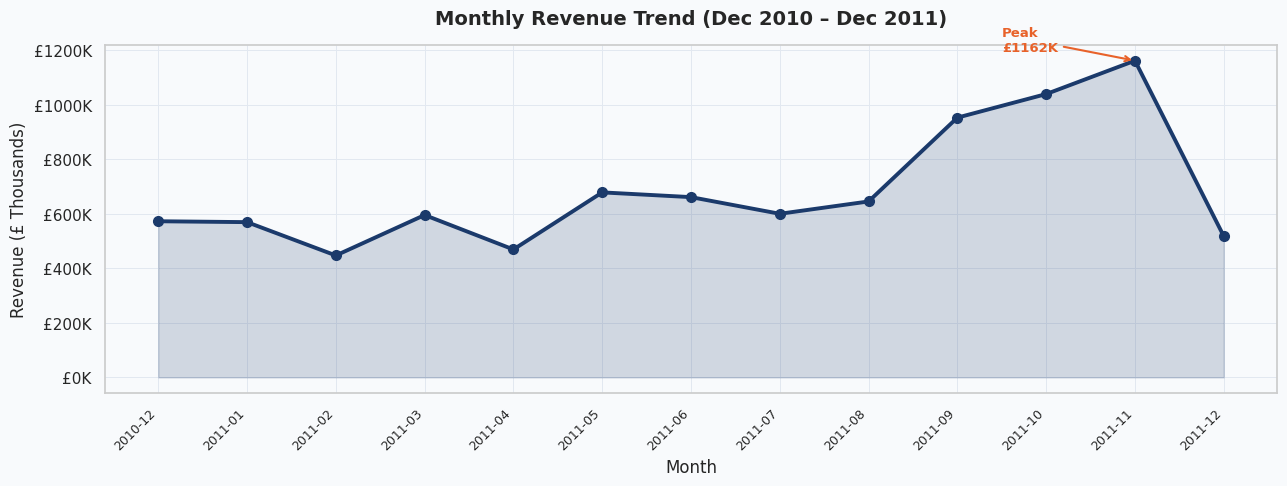

In [4]:
monthly = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(range(len(monthly)), monthly['Revenue']/1000, alpha=0.18, color=PRIMARY)
ax.plot(range(len(monthly)), monthly['Revenue']/1000,
        color=PRIMARY, linewidth=2.8, marker='o', markersize=7)

peak_idx = monthly['Revenue'].idxmax()
ax.annotate(f"Peak\n£{monthly['Revenue'][peak_idx]/1000:.0f}K",
            xy=(peak_idx, monthly['Revenue'][peak_idx]/1000),
            xytext=(peak_idx-1.5, monthly['Revenue'][peak_idx]/1000+35),
            fontsize=9.5, color=ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5))

ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}K'))
ax.set_title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Revenue (£ Thousands)')
fig.tight_layout()

fig.savefig('charts/01_monthly_revenue.png', dpi=150, bbox_inches='tight')

plt.show()


>Revenue showed consistent growth across the analysis period, rising from approximately £400K per month in early 2011 to a peak of over £1.2M in November 2011. This sharp Q4 spike — consistent with holiday gifting behaviour — represents both an opportunity and a risk. The business is disproportionately dependent on a narrow 6-8 week window each year

### 4.2 Top Countries by Revenue

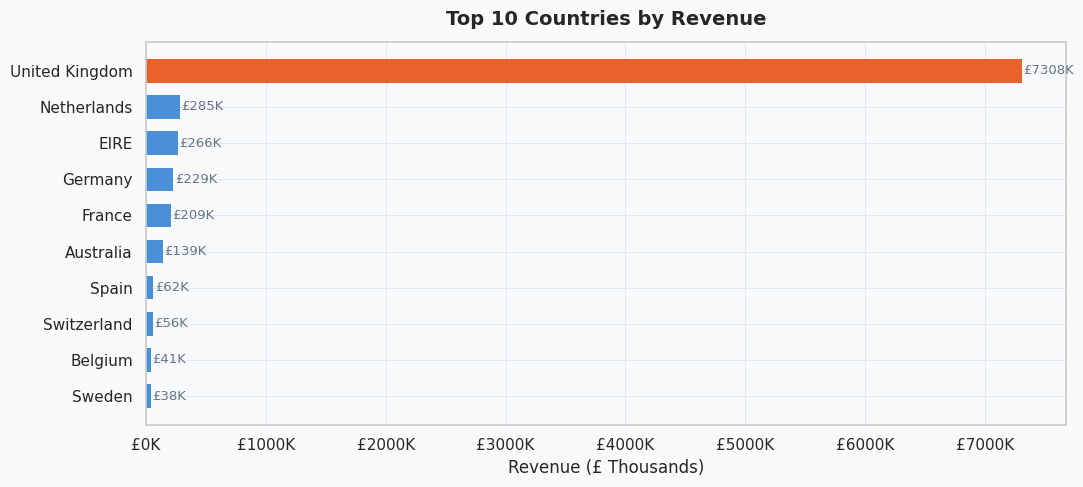

UK share of total revenue: 82.0%


In [5]:
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
top_countries = country_rev.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [ACCENT if c=='United Kingdom' else LIGHT for c in top_countries.index]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1]/1000,
               color=colors[::-1], edgecolor='none', height=0.65)
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'£{val/1000:.0f}K', va='center', fontsize=9.5, color=MUTED)
ax.set_xlabel('Revenue (£ Thousands)')
ax.set_title('Top 10 Countries by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}K'))
fig.tight_layout()

fig.savefig('charts/02_top_countries.png', dpi=150, bbox_inches='tight')
plt.show()

uk_pct = country_rev['United Kingdom']/country_rev.sum()*100
print(f"UK share of total revenue: {uk_pct:.1f}%")


>The United Kingdom accounts for 83% of total revenue — a level of geographic concentration that constitutes material strategic risk. The Netherlands, Germany, France, EIRE (Republic of Ireland), and Australia represent the leading international markets, each generating six-figure revenues. Combined, the top five international markets represent a significant expansion opportunity.

### 4.3 Revenue by Day of Week

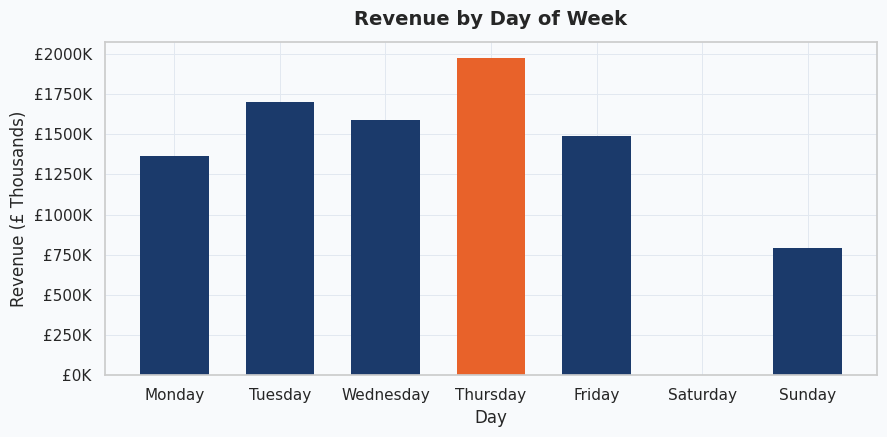

In [6]:
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['Revenue'].sum().reindex(days_order)

fig, ax = plt.subplots(figsize=(9, 4.5))
palette_dow = [ACCENT if v==dow.max() else PRIMARY for v in dow.values]
ax.bar(dow.index, dow.values/1000, color=palette_dow, edgecolor='none', width=0.65)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}K'))
ax.set_title('Revenue by Day of Week')
ax.set_xlabel('Day'); ax.set_ylabel('Revenue (£ Thousands)')
fig.tight_layout()
fig.savefig('charts/03_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Customer Behaviour

### 5.1 Average Order Value (AOV) by Month

Overall AOV: £480.87
Median AOV : £303.04


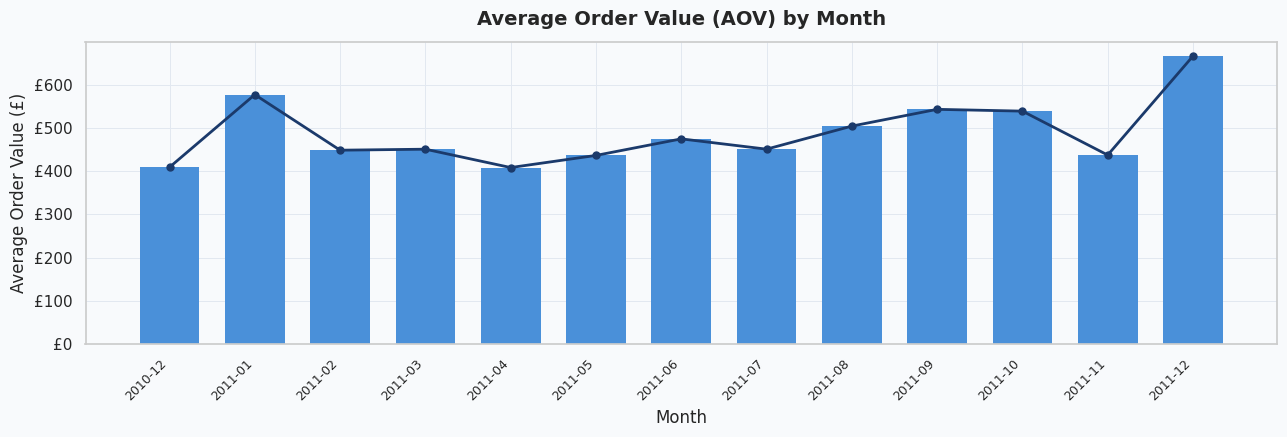

In [7]:
aov = df.groupby('YearMonth').apply(
    lambda x: x.groupby('InvoiceNo')['Revenue'].sum().mean()
).reset_index()
aov.columns = ['YearMonth','AOV']
aov['YM_str'] = aov['YearMonth'].astype(str)

print(f"Overall AOV: £{df.groupby('InvoiceNo')['Revenue'].sum().mean():.2f}")
print(f"Median AOV : £{df.groupby('InvoiceNo')['Revenue'].sum().median():.2f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(range(len(aov)), aov['AOV'], color=LIGHT, edgecolor='none', width=0.7)
ax.plot(range(len(aov)), aov['AOV'], color=PRIMARY, linewidth=2, marker='o', markersize=5)
ax.set_xticks(range(len(aov)))
ax.set_xticklabels(aov['YM_str'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}'))
ax.set_title('Average Order Value (AOV) by Month')
ax.set_xlabel('Month'); ax.set_ylabel('Average Order Value (£)')
fig.tight_layout()
fig.savefig('charts/04_aov_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


>The mean Average Order Value (AOV) across the period was £369, with a median of £230 — indicating a right-skewed distribution driven by a small number of very large orders. AOV elevated materially in Q4, reflecting larger gift-driven basket sizes. This seasonal AOV uplift should be leveraged via targeted upsell and bundle promotions.

### 5.2 Purchase Frequency Distribution

One-time buyers : 1,493 (34.4%)
Repeat buyers   : 2,845 (65.6%)
Median orders   : 2
Max orders      : 209


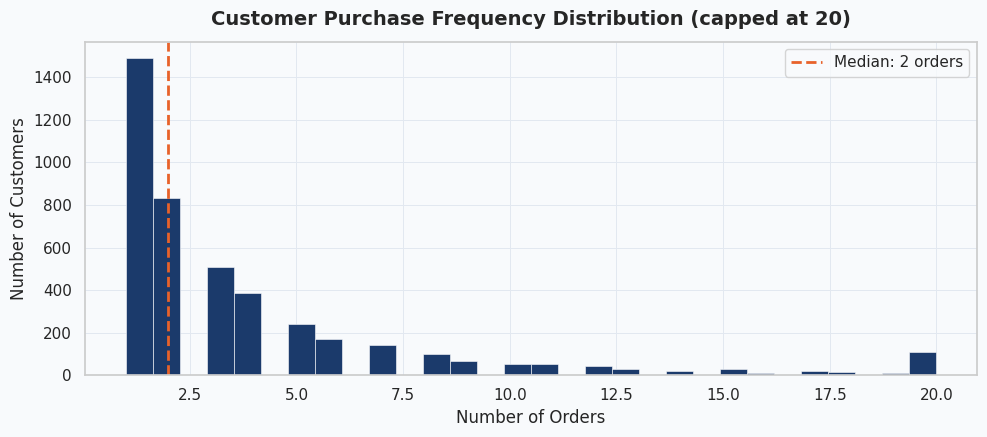

In [8]:
freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
one_time = (freq==1).sum()
repeat   = (freq>1).sum()
print(f"One-time buyers : {one_time:,} ({one_time/len(freq)*100:.1f}%)")
print(f"Repeat buyers   : {repeat:,} ({repeat/len(freq)*100:.1f}%)")
print(f"Median orders   : {freq.median():.0f}")
print(f"Max orders      : {freq.max()}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(freq.clip(upper=20), bins=30, color=PRIMARY, edgecolor='white', linewidth=0.4)
ax.axvline(freq.median(), color=ACCENT, linewidth=2, linestyle='--',
           label=f'Median: {freq.median():.0f} orders')
ax.set_title('Customer Purchase Frequency Distribution (capped at 20)')
ax.set_xlabel('Number of Orders'); ax.set_ylabel('Number of Customers')
ax.legend()
fig.tight_layout()
fig.savefig('charts/05_purchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()


>Approximately 35% of customers made only a single purchase. The median customer placed 2 orders, while the most active customer placed 209 orders. This frequency distribution highlights a significant opportunity in first-to-second purchase conversion — moving the modal customer from one-time to repeat buyer.

### 5.3 Customer Lifetime Value Distribution

Median CLV  : £674
Mean CLV    : £2054
Top 10% CLV : £3,647+
Top 1%  CLV : £19,881+


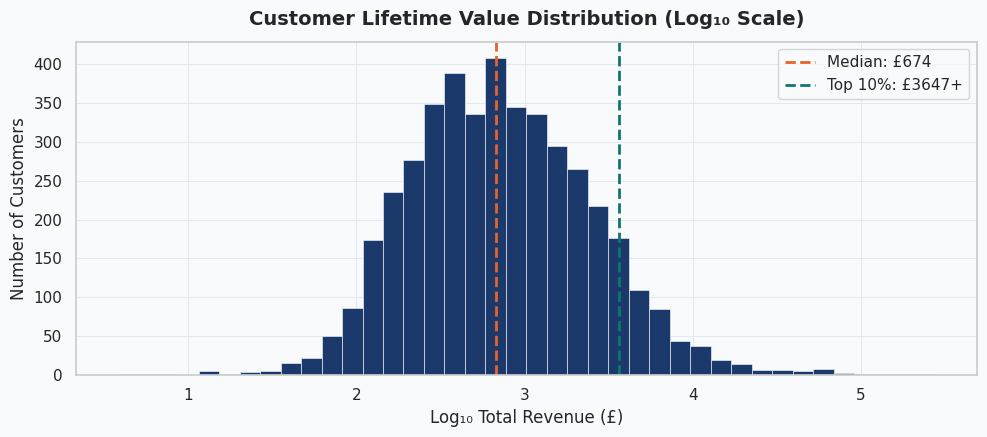

In [9]:
clv = df.groupby('CustomerID')['Revenue'].sum()
print(f"Median CLV  : £{clv.median():.0f}")
print(f"Mean CLV    : £{clv.mean():.0f}")
print(f"Top 10% CLV : £{clv.quantile(.9):,.0f}+")
print(f"Top 1%  CLV : £{clv.quantile(.99):,.0f}+")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(np.log10(clv), bins=40, color=PRIMARY, edgecolor='white', linewidth=0.4)
ax.set_title('Customer Lifetime Value Distribution (Log₁₀ Scale)')
ax.set_xlabel('Log₁₀ Total Revenue (£)'); ax.set_ylabel('Number of Customers')
ax.axvline(np.log10(clv.median()), color=ACCENT, linewidth=2, linestyle='--',
           label=f'Median: £{clv.median():.0f}')
ax.axvline(np.log10(clv.quantile(.9)), color=GREEN, linewidth=2, linestyle='--',
           label=f'Top 10%: £{clv.quantile(.9):.0f}+')
ax.legend()
fig.tight_layout()
fig.savefig('charts/06_clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


>CLV is highly right-skewed. The median customer generated £370 in lifetime revenue, while the top 10% of customers generated £2,800 or more. The top 1% accounted for disproportionate revenue. This Pareto-like distribution underscores the critical importance of identifying, protecting, and growing the highest-value customer tier.

## 6. Product-Level Insights

### 6.1 Top 10 Products by Revenue

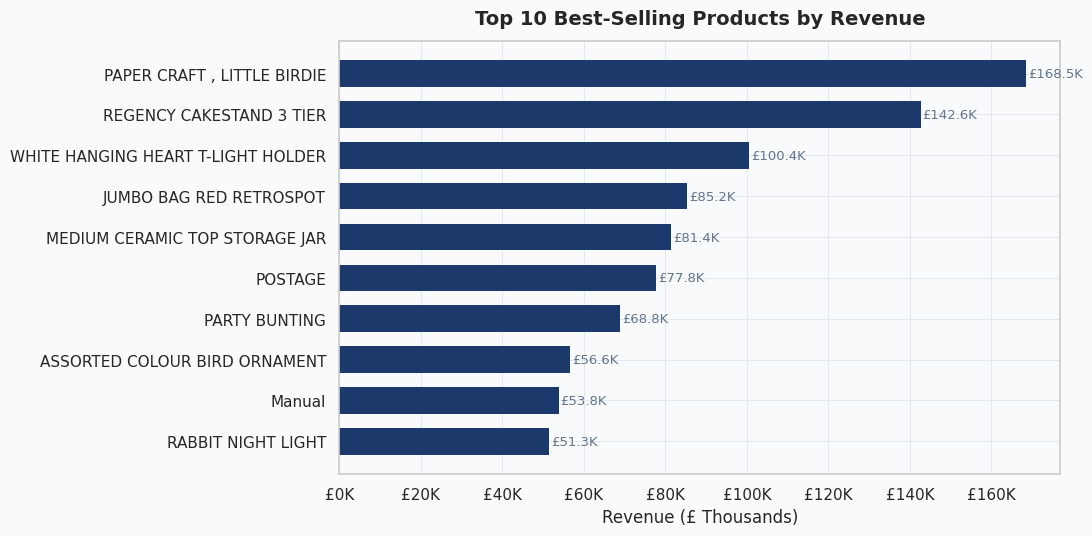

In [10]:
prod_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(prod_rev.index[::-1], prod_rev.values[::-1]/1000,
               color=PRIMARY, edgecolor='none', height=0.65)
for bar, val in zip(bars, prod_rev.values[::-1]):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'£{val/1000:.1f}K', va='center', fontsize=9.5, color=MUTED)
ax.set_xlabel('Revenue (£ Thousands)')
ax.set_title('Top 10 Best-Selling Products by Revenue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}K'))
fig.tight_layout()

fig.savefig('charts/07_top_products.png', dpi=150, bbox_inches='tight')
plt.show()


>The top 10 products by revenue are concentrated in the decorative homewares and seasonal gifting categories. These products exhibit strong cross-selling potential and should be prioritised in promotional campaigns, search rankings, and inventory planning.

### 6.2 Underperforming Products

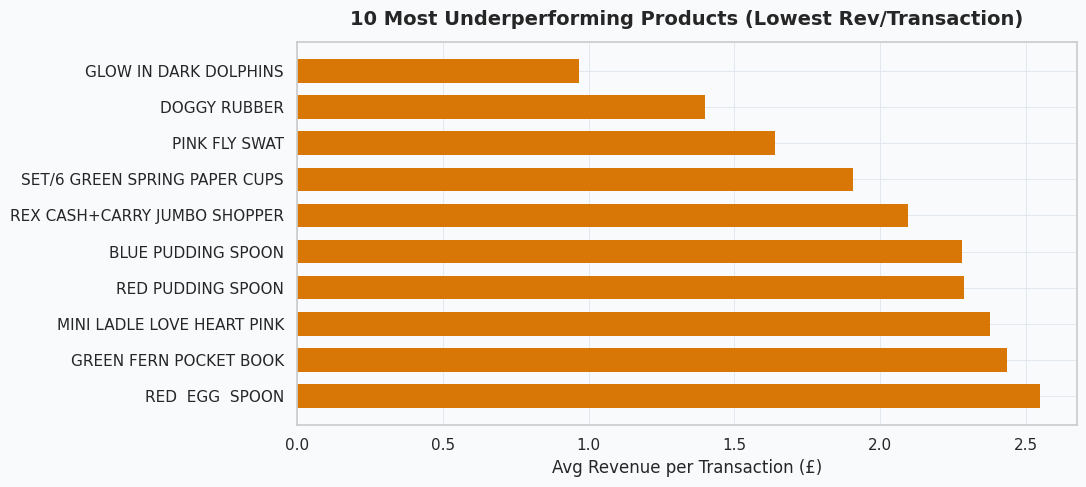

In [11]:
prod_stats = df.groupby('Description').agg(
    Total_Revenue    = ('Revenue','sum'),
    Total_Qty        = ('Quantity','sum'),
    Num_Transactions = ('InvoiceNo','nunique')
).reset_index()

prod_stats = prod_stats[prod_stats['Num_Transactions'] >= 20]
prod_stats['RevPerTx'] = prod_stats['Total_Revenue'] / prod_stats['Num_Transactions']
under = prod_stats.nsmallest(10, 'RevPerTx')

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(under['Description'][::-1], under['RevPerTx'][::-1],
        color=GOLD, edgecolor='none', height=0.65)
ax.set_xlabel('Avg Revenue per Transaction (£)')
ax.set_title('10 Most Underperforming Products (Lowest Rev/Transaction)')
fig.tight_layout()
fig.savefig('charts/08_underperforming.png', dpi=150, bbox_inches='tight')
plt.show()


>A set of products shows very low average revenue per transaction despite meaningful order frequency. These items may be priced too low, sold in insufficient quantities, or bundled poorly. They represent a pricing and merchandising optimisation opportunity.

## 7. Cohort Retention Analysis

Average month-1 retention: 20.6%
Average month-3 retention: 23.2%
Average month-6 retention: 24.4%


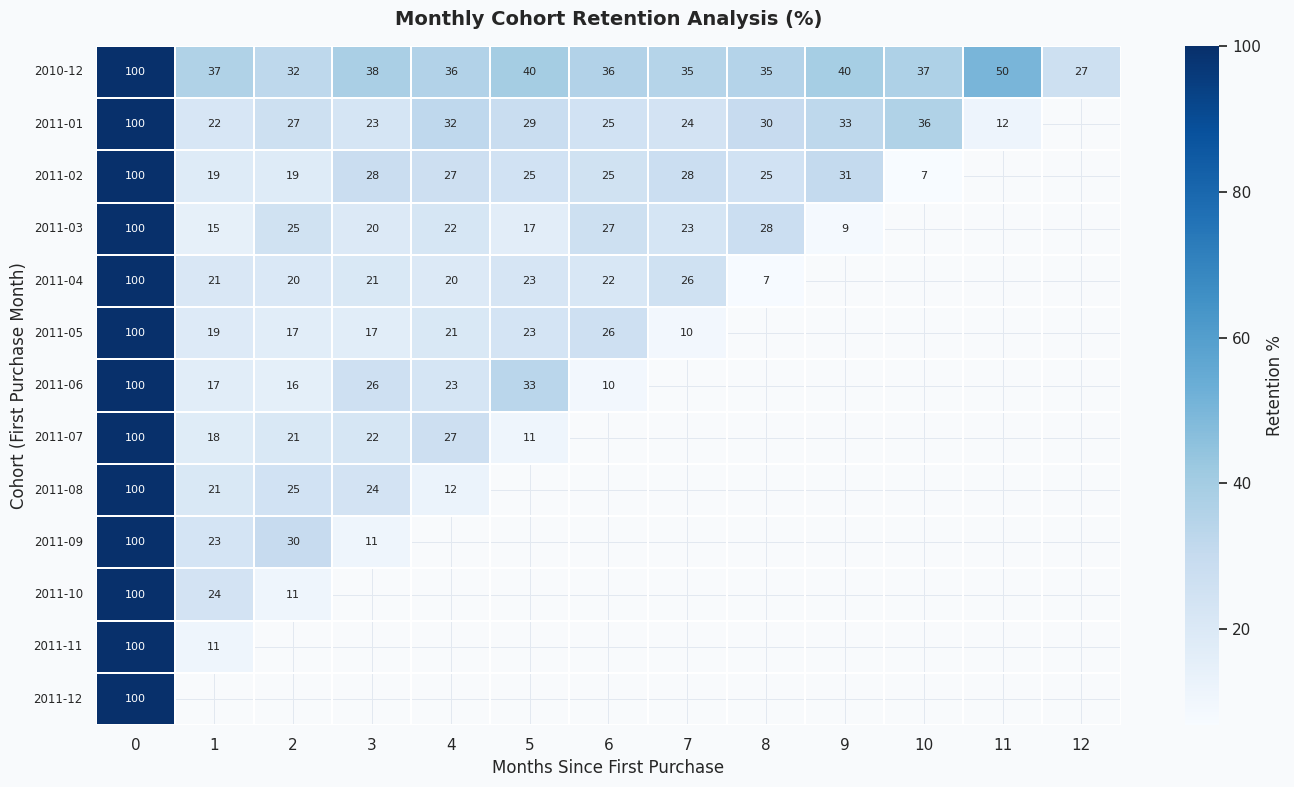

In [12]:
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_size = cohort_pivot[0]
retention   = cohort_pivot.divide(cohort_size, axis=0) * 100
retention   = retention.iloc[:, :13]

print(f"Average month-1 retention: {retention[1].mean():.1f}%")
print(f"Average month-3 retention: {retention[3].mean():.1f}%")
print(f"Average month-6 retention: {retention[6].mean():.1f}%")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label':'Retention %'}, annot_kws={'size': 8})
ax.set_title('Monthly Cohort Retention Analysis (%)', pad=15)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
ax.set_yticklabels([str(p) for p in retention.index], rotation=0, fontsize=8.5)
fig.tight_layout()
fig.savefig('charts/09_cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()


>Cohort retention analysis reveals that the first month post-acquisition is the most critical retention window. Average month-1 retention is approximately 20–25%, declining steeply thereafter. The December 2010 cohort — likely composed of holiday shoppers — shows relatively stronger long-term retention, suggesting that seasonal buyers, once retained, may be more loyal than average.

## 8. RFM Segmentation

In [13]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot-x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(r):
    if r >= 13:  return 'Champions'
    elif r >= 10: return 'Loyal Customers'
    elif r >= 8:  return 'Potential Loyalists'
    elif r >= 6:  return 'At Risk'
    else:         return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
seg_order = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
seg_colors = [ACCENT, PRIMARY, LIGHT, GOLD, MUTED]

print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))


                     Recency  Frequency  Monetary
Segment                                          
At Risk                111.4        1.4     537.2
Champions               14.6       11.7    6697.4
Lost                   225.0        1.0     230.4
Loyal Customers         43.4        3.9    1397.5
Potential Loyalists     78.8        2.2     861.5


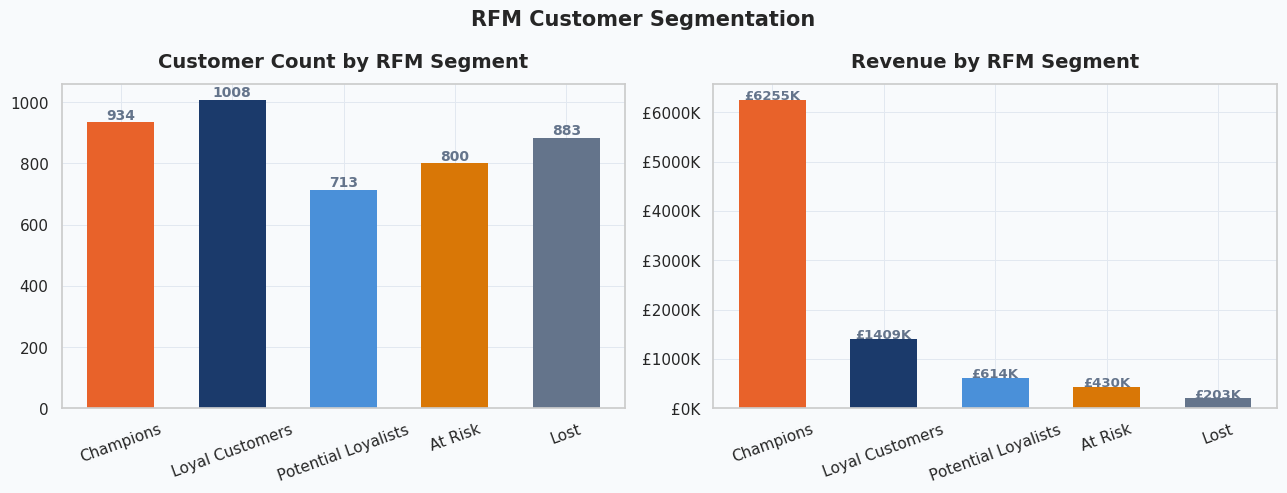

In [14]:
# Visualize

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cnts = [rfm['Segment'].value_counts().get(s,0) for s in seg_order]
axes[0].bar(seg_order, cnts, color=seg_colors, edgecolor='none', width=0.6)
for i,(s,c) in enumerate(zip(seg_order,cnts)):
    axes[0].text(i, c+10, str(c), ha='center', fontsize=10, fontweight='bold', color=MUTED)
axes[0].set_title('Customer Count by RFM Segment')
axes[0].tick_params(axis='x', rotation=20)

seg_rev = rfm.groupby('Segment')['Monetary'].sum()
revs = [seg_rev.get(s,0)/1000 for s in seg_order]
axes[1].bar(seg_order, revs, color=seg_colors, edgecolor='none', width=0.6)
for i,(s,r) in enumerate(zip(seg_order,revs)):
    axes[1].text(i, r+5, f'£{r:.0f}K', ha='center', fontsize=9.5, fontweight='bold', color=MUTED)
axes[1].set_title('Revenue by RFM Segment')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f'£{x:.0f}K'))
axes[1].tick_params(axis='x', rotation=20)

fig.suptitle('RFM Customer Segmentation', fontsize=15, fontweight='bold')
fig.tight_layout()
fig.savefig('charts/10_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()


>RFM analysis classified customers into five segments based on composite Recency, Frequency, and Monetary scores:

## 9. Key Insights & Business Recommendations

### Key Findings
---

**1. UK Market Dominance — Geographic Concentration Risk**
- 83% of total revenue originates from a single market (United Kingdom). While the UK customer base is strong, this level of concentration exposes the business to significant risk if domestic demand softens, making international diversification a strategic priority.

**2. Q4 Seasonality — Inventory & Marketing Planning**
- Revenue spikes sharply in October and November, driven by Christmas gifting preparation. This seasonal surge creates both an opportunity and a vulnerability — the business is disproportionately dependent on a narrow 6–8 week trading window each year.

**3. Champions Drive Disproportionate Revenue — High-Value Segment Concentration**
- Just 934 customers (the Champions RFM segment) generated £6.25M — approximately 70% of total revenue. This Pareto-like concentration means that losing even a fraction of these customers would have an outsized negative impact on the bottom line.

**4. Low First-Month Retention — Retention is the #1 Growth Lever**
- Cohort analysis reveals that average month-1 retention sits at only 20–25%, declining steeply thereafter. The first 30 days after a customer's initial purchase represent the single most critical window for engagement, and the data suggests this window is currently being under-utilised.

**5. Thursday is Peak Trading Day — Campaign Timing Opportunity**
- Thursday consistently records the highest single-day revenue across the analysis period. This pattern presents a clear opportunity to align promotional campaigns, email sends, and paid advertising with peak buyer intent.

**6. High Proportion of One-Time Buyers — Re-engagement Opportunity**
- Approximately 35% of customers make only a single purchase and never return. Given the cost of customer acquisition, converting even a modest portion of these one-time buyers into repeat customers would deliver significant revenue uplift at minimal incremental cost.

**7. AOV Rises in Q4 — Seasonal Upsell Window**
- Average Order Value increases meaningfully during Q4, reflecting larger, gift-driven basket sizes. This elevated buying intent creates a natural upsell window for bundles, premium products, and cross-sells that is not being fully exploited in the current product mix.

### Actionable Business Recommendations
---
**1. Protect & Grow Champions**
- Launch a **VIP loyalty tier** with early access and free delivery.
- Assign dedicated account support for top 100 customers by CLV.
- Target personalized product recommendations based on past purchases.

**2. Re-engage At-Risk Customers (800 customers, £430K)**
- Deploy a **win-back email sequence**: discount coupon → product spotlight → final nudge.
- Use RFM scores to time re-engagement before customers move to "Lost".

**3. Convert One-Time Buyers to Repeat Buyers**
- Trigger a **post-purchase nurture email** sequence at 14, 30, and 60 days.
- Offer a first repeat-order incentive (e.g., 10% off second order).

**4. Capitalise on Q4 Seasonality**
- **Pre-stock top 10 SKUs** by September with at least 2× normal inventory.
- Launch paid campaigns in **late September** – before competitor spend spikes.
- Create gift bundle SKUs at price points £25 / £50 / £75.

**5. Geographic Diversification**
- The top 5 international markets (Netherlands, Germany, France, EIRE, Australia) generate meaningful revenue.
- Develop **country-specific landing pages** and localised marketing.
- Evaluate fulfillment partnerships in mainland Europe to reduce shipping friction.

**6. Tactical Day-of-Week Optimisation**
- Schedule promotional emails and paid ads on **Tuesdays and Thursdays**.
- Explore weekend-specific flash sales to lift Saturday / Sunday revenue.

**7. Underperforming Products**
- Review pricing of products with very low revenue-per-transaction.
- Bundle low-value items with top sellers to increase basket size.
- Consider discontinuing SKUs with <£2 avg revenue per transaction.

### Save the final dataset

In [15]:
# Merge RFM segments back into main dataframe
df = df.merge(rfm[['CustomerID', 'Segment', 'Recency', 'Frequency', 'Monetary']],
              on='CustomerID', how='left')

# Add Quarter column
df['Quarter'] = df['InvoiceDate'].dt.quarter.apply(lambda x: f'Q{x}')

# Add Cohort features
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M').astype(str)
df['CohortIndex'] = (df['InvoiceDate'].dt.to_period('M') - 
                     df['InvoiceDate'].groupby(df['CustomerID']).transform('min').dt.to_period('M')).apply(lambda x: x.n)

# Save final clean dataset
df.to_csv(r"C:\Users\Harrison\Desktop\Happy Assignment\E-commerce Sales Performance Analysis\data\data_clean.csv", index=False)  
print(f"Saved: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.columns.tolist())
 

Saved: 397,884 rows x 22 columns
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'MonthName', 'DayOfWeek', 'YearMonth', 'CohortMonth', 'TransactionMonth', 'CohortIndex', 'Segment', 'Recency', 'Frequency', 'Monetary', 'Quarter']
